## Preparing The Data

In [4]:
import csv
from pathlib import Path

root_dir = Path('data') 
output_csv = 'MNIST_Medical_Dataset.csv'

image_extensions = {'.jpg', '.jpeg', '.png'}
data = []

print("Scanning folders...")

for folder in root_dir.iterdir():
    if folder.is_dir():
        # I will use the folder name as our label (e.g., AbdomenCT, CXR)
        label = folder.name
        
        for file in folder.iterdir():
            if file.suffix.lower() in image_extensions:
                data.append([str(file), label])

# Turns into CSV file
with open(output_csv, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['file_path', 'label'])
    writer.writerows(data)

print(f"Success! Created {output_csv} with {len(data)} entries.")

Scanning folders...
Success! Created MNIST_Medical_Dataset.csv with 58954 entries.


In [10]:
from sklearn.model_selection import train_test_split

# Convert labels to codes
df['label_code'] = pd.Categorical(df['label']).codes
# IMPORTANT: Save your class names now since you're using a custom CSV!
class_names = pd.Categorical(df['label']).categories.tolist()

# SPLIT THE DATAFRAME
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# create a dataset from a dataframe
def create_tf_dataset(dataframe):
    paths = dataframe['file_path'].values
    labels = dataframe['label_code'].values
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

# Create two separate pipelines
train_ds = create_tf_dataset(train_df).shuffle(len(train_df)).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = create_tf_dataset(test_df).batch(32).prefetch(tf.data.AUTOTUNE)

print(f"Training images: {len(train_df)}")
print(f"Testing images: {len(test_df)}")
print(f"Classes: {class_names}")

Training images: 47163
Testing images: 11791
Classes: [0, 1, 2, 3, 4, 5]


In [13]:
class_names = pd.Categorical(df['label']).categories.tolist()
class_names

[0, 1, 2, 3, 4, 5]

In [14]:
train_df

,file_path,label,label_code
50836,data\HeadCT\001882.jpeg,5,5
55682,data\HeadCT\006728.jpeg,5,5
42047,data\Hand\003093.jpeg,4,4
35346,data\CXR\006392.jpeg,2,2
50477,data\HeadCT\001523.jpeg,5,5
...,...,...,...
54343,data\HeadCT\005389.jpeg,5,5
38158,data\CXR\009204.jpeg,2,2
860,data\AbdomenCT\000860.jpeg,0,0
15795,data\BreastMRI\005795.jpeg,1,1


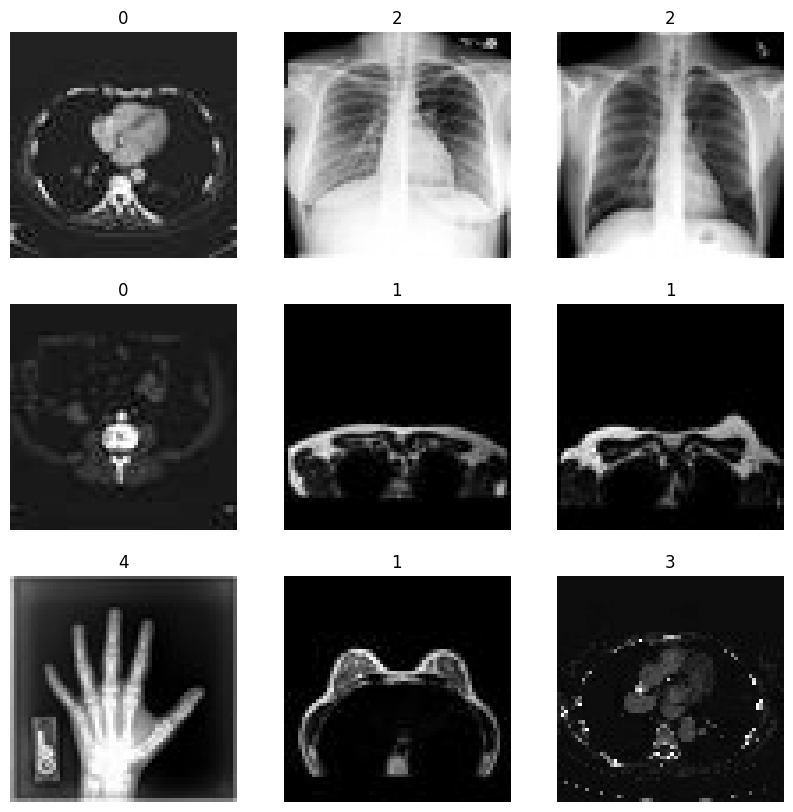

In [16]:
import matplotlib.pyplot as plt

# Take one batch (32 images) from dataset
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9): # Show the first 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("float32").squeeze(), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

## Training The Model

In [18]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # First Convolutional block (finds basic edges)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Second Convolutional block (finds more complex shapes)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Third Convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    
    # Flattening 2D maps into a 1D vector
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    
    # Output layer: one neuron per class
    layers.Dense(num_classes, activation='softmax')
])

D:\Programming\Personal Project\MedicalMNIST\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         589,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 646,022 (2.46 MB)

 Trainable params: 646,022 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
EPOCHS = 10 

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 291s 182ms/step - accuracy: 0.9855 - loss: 0.0504 - val_accuracy: 0.9970 - val_loss: 0.0125
Epoch 2/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 150s 90ms/step - accuracy: 0.9980 - loss: 0.0071 - val_accuracy: 0.9979 - val_loss: 0.0071
Epoch 3/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 110s 71ms/step - accuracy: 0.9975 - loss: 0.0090 - val_accuracy: 0.9991 - val_loss: 0.0039
Epoch 4/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 109s 70ms/step - accuracy: 0.9992 - loss: 0.0028 - val_accuracy: 0.9985 - val_loss: 0.0053
Epoch 5/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 108s 70ms/step - accuracy: 0.9978 - loss: 0.0070 - val_accuracy: 0.9987 - val_loss: 0.0047
Epoch 6/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 106s 69ms/step - accuracy: 0.9986 - loss: 0.0053 - val_accuracy: 0.9986 - val_loss: 0.0058
Epoch 7/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 107s 69ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9988 - val_loss: 0.0058
Epoch 8/10
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 105s 68ms/step - accuracy:

## Test Model

In [24]:
# Evaluate overall accuracy
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

369/369 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9992 - loss: 0.0029

Test Accuracy: 99.92%


In [25]:
# Predict on a single batch from the test set
for images, labels in test_ds.take(10):
    predictions = model.predict(images)
    predicted_class_index = tf.argmax(predictions[0]).numpy()
    
    print(f"Actual Label: {class_names[labels[0].numpy()]}")
    print(f"Model Predicted: {class_names[predicted_class_index]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Actual Label: 0
Model Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Actual Label: 4
Model Predicted: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Actual Label: 1
Model Predicted: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Actual Label: 2
Model Predicted: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Actual Label: 0
Model Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Actual Label: 0
Model Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Actual Label: 0
Model Predicted: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Actual Label: 2
Model Predicted: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Actual Label: 3
Model Predicted: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Actual Label: 5
Model Predicted: 5


In [26]:
model.save('medical_mnist_v1.keras')